Caso Ótimo

In [30]:
import pandas as pd
import py_dss_interface
from py_dss_toolkit import dss_tools

dss_file = r"C:\Dados_teste\OpenDSS\GWO\Alim_Meia_Ponte_5_REDUZIDO\Master_PyDSS_Interface.dss"

dss = py_dss_interface.DSS()

dss_tools.update_dss(dss)

dss.text(f"compile [{dss_file}]")

def decide_element(bus: str, buses_df: pd.DataFrame, trafo_df: pd.DataFrame, lines_df: pd.DataFrame):
    bus = bus.split(".")[0]
    elements_query = buses_df.query(f"name == '{bus}'")["all_pde_active_bus"].iloc[0]

    distance = 1e6
    for element in elements_query:
        element_type, element_name = element.split(".")

        if element_type == "Line":
            segment_df = lines_df.query(f"name == '{element_name}'")

            element_bus = segment_df["bus_name"].iloc[0]
            distance_bus = buses_df.query(f"name == '{element_bus}'")["distance"].iloc[0]

            if "mt" in element_name:
                kv = 13.8

            elif "bt" in element_name:
                kv = 0.38

            else:
                continue

        elif element_type == "Transformer":
            element_bus = trafo_df.query(f"name == '{element_name}'")["bus_name"].iloc[0]
            distance_bus = buses_df.query(f"name == '{element_bus}'")["distance"].iloc[0]
            kv = trafo_df.query(f"name == '{element_name}'")["kv"].iloc[0]

        else:
            continue

        if distance_bus < distance:
            distance = distance_bus
            selected_element = element_name
            selected_element_type = element_type
            selected_kv = kv

    return selected_element_type, selected_element, selected_kv

buses_df = dss_tools.model.buses_df
trafo_df = dss_tools.model.transformers_df
lines_df = dss_tools.model.lines_df

trafo_df["bus_name"] = trafo_df["bus"].str.split(".").str[0]
lines_df["bus_name"] = lines_df["bus1"].str.split(".").str[0]

buses_df = buses_df[["name", "distance", "all_pce_active_bus", "all_pde_active_bus"]]


,name,kwh,kvarh,max kw,max kva,zone kwh,zone kvarh,zone max kw,zone max kva,overload kwh normal,...,aux19,aux24,aux29,13.8 kv load energy,aux5,aux10,aux15,aux20,aux25,aux30
0,busa4-_2021126072_segmmt_53951427,98888.831402,130939.244182,7065.687191,8103.461649,241001.97244,103097.85506,6612.56024,7223.772169,1316.304124,...,0.0,0.0,0.0,241001.97244,0.0,0.0,0.0,0.0,0.0,0.0


,name,kwh,kvarh,max kw,max kva,zone kwh,zone kvarh,zone max kw,zone max kva,overload kwh normal,...,aux19,aux24,aux29,13.8 kv load energy,aux5,aux10,aux15,aux20,aux25,aux30
0,busa4-_2021126072_segmmt_53951427,98579.167312,128984.483401,6769.131094,7811.870229,241212.107369,103148.962729,6640.376759,7253.902988,693.384172,...,0.0,0.0,0.0,241212.107369,0.0,0.0,0.0,0.0,0.0,0.0


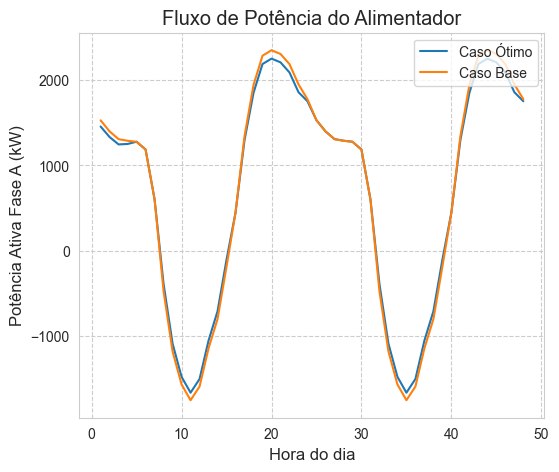

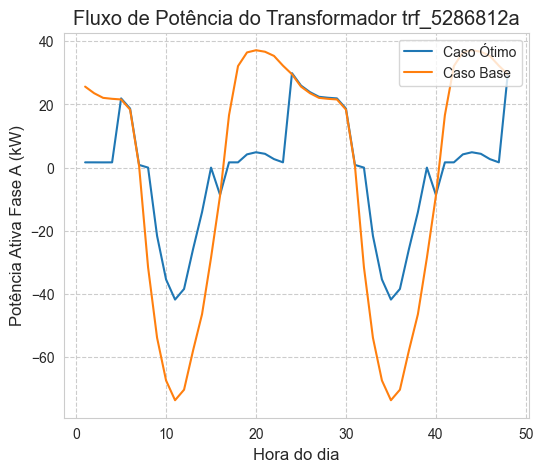

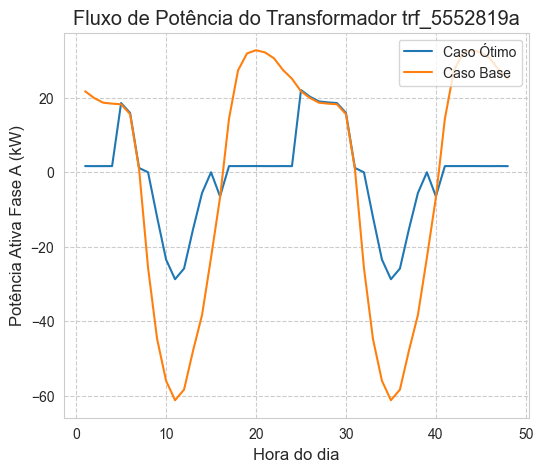

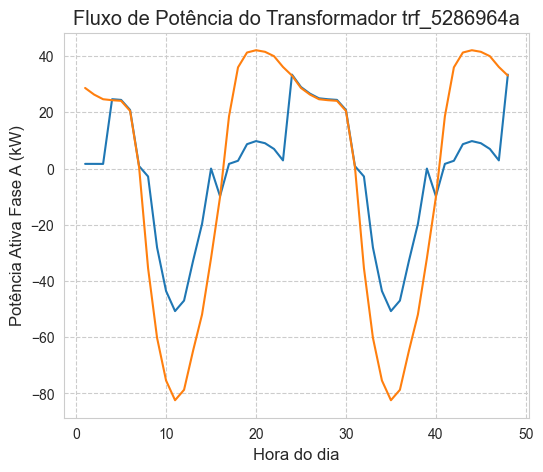

In [35]:
import py_dss_interface
from py_dss_toolkit import dss_tools
from matplotlib import pyplot as plt

cases = ["BaseCase", "OptimalCase"]
solution_buses = ['82036275286964.1.2.3.4', '82026915286812.1.2.3.4', '82032765552819.1.2.3.4']

dss_file = r"C:\Dados_teste\OpenDSS\GWO\Alim_Meia_Ponte_5_REDUZIDO\Master_PyDSS_Interface.dss"

dss = py_dss_interface.DSS()

dss_tools.update_dss(dss)

for case in cases:

    dss.text(f"compile [{dss_file}]")

    dss.text("Redirect 'PV_System_120_MeiaPonte.dss'")

    if case == "OptimalCase":

        for i, bus in enumerate(solution_buses):
            element_type, element_name, kv = decide_element(bus, buses_df, trafo_df, lines_df)

            dss.text(f"New Storage.Battery_{i} phases=3 bus1={bus} kv={kv} kWrated=100 kWhrated=800 dispmode=follow %stored=50")
            
            dss.text(f"New StorageController.SC_{i} element={element_type}.{element_name} terminal=1 modedis=peakShave elementList=[Battery_{i}]\n"
            f"~ MonPhase=AVG kwtarget=5 modecharge=peakShaveLow kwtargetLow=0\n\n")

    dss.text(f"buscoords BusCoords.csv")

    dss.text("set mode=daily")
    dss.text("set stepsize=1h")
    dss.text("set number=48")

    dss.solution.solve()

    energymeter_df = dss_tools.results.energymeters

    elem_1, elem_2, elem_3 = "trf_5286812a", "trf_5552819a", "trf_5286964a"

    if case == "OptimalCase":
        df_optimal_feeder = dss_tools.results.monitor("feeder")
        df_optimal_trafo_1 = dss_tools.results.monitor(elem_1)
        df_optimal_trafo_2 = dss_tools.results.monitor(elem_2)
        df_optimal_trafo_3 = dss_tools.results.monitor(elem_3)

    elif case == "BaseCase":
        df_base_feeder = dss_tools.results.monitor("feeder")
        df_base_trafo_1 = dss_tools.results.monitor(elem_1)
        df_base_trafo_2 = dss_tools.results.monitor(elem_2)
        df_base_trafo_3  = dss_tools.results.monitor(elem_3)

    display(energymeter_df)

#### Gráfico

# Alimentador
plt.plot(df_optimal_feeder["Hour"], df_optimal_feeder[" P1 (kW)"], label="Caso Ótimo")
plt.plot(df_optimal_feeder["Hour"], df_base_feeder[" P1 (kW)"], label="Caso Base")
plt.xlabel("Hora do dia")
plt.ylabel("Potência Ativa Fase A (kW)")
plt.legend()
plt.grid(True)
plt.title("Fluxo de Potência do Alimentador")
plt.show()

#Trafo 5286812a
plt.plot(df_optimal_trafo_1["Hour"], df_optimal_trafo_1[" P1 (kW)"], label="Caso Ótimo")
plt.plot(df_optimal_trafo_1["Hour"], df_base_trafo_1[" P1 (kW)"], label="Caso Base")
plt.xlabel("Hora do dia")
plt.ylabel("Potência Ativa Fase A (kW)")
plt.legend()
plt.grid(True)
plt.title(f"Fluxo de Potência do Transformador {elem_1}")
plt.show()

#Trafo 5552819a

plt.plot(df_optimal_trafo_2["Hour"], df_optimal_trafo_2[" P1 (kW)"], label="Caso Ótimo")
plt.plot(df_optimal_trafo_2["Hour"], df_base_trafo_2[" P1 (kW)"], label="Caso Base")
plt.xlabel("Hora do dia")
plt.ylabel("Potência Ativa Fase A (kW)")
plt.legend()
plt.grid(True)
plt.title(f"Fluxo de Potência do Transformador {elem_2}")
plt.show()

#Trafo 5286964a

plt.plot(df_optimal_trafo_3["Hour"], df_optimal_trafo_3[" P1 (kW)"])
plt.plot(df_optimal_trafo_3["Hour"], df_base_trafo_3[" P1 (kW)"])
plt.xlabel("Hora do dia")
plt.ylabel("Potência Ativa Fase A (kW)")
plt.grid(True)
plt.title(f"Fluxo de Potência do Transformador {elem_3}")
plt.show()


Análise dos Barramentos Selecionados

In [2]:
buses_df = dss_tools.model.buses_df
display(buses_df.query("name in ['82036275286964', '82026915286812', '82032765552819']"))

,name,nodes,num_nodes,kv_base,distance,coord_defined,x,y,latitude,longitude,all_pce_active_bus,all_pde_active_bus,line_list,line_total_miles,load_list,section_id,total_customers
1103,82026915286812,"[1, 2, 3, 4]",4,0.219393,8.798261,1,-49.334312,-16.624640,0.0,0.0,"[Load.m2_trf_5286812a, Load.m1_trf_5286812a, R...",[Transformer.trf_5286812a],[None],0.0,"[LOAD.m2_trf_5286812a, LOAD.m1_trf_5286812a]",0,0
1186,82032765552819,"[1, 2, 3, 4]",4,0.219393,7.166839,1,-49.323548,-16.614623,0.0,0.0,"[Load.m2_trf_5552819a, Load.m1_trf_5552819a, R...",[Transformer.trf_5552819a],[None],0.0,"[LOAD.m2_trf_5552819a, LOAD.m1_trf_5552819a]",0,0
1201,82036275286964,"[1, 2, 3, 4]",4,0.219393,5.884288,1,-49.320532,-16.615113,0.0,0.0,"[Load.m2_trf_5286964a, Load.m1_trf_5286964a, R...",[Transformer.trf_5286964a],[None],0.0,"[LOAD.m2_trf_5286964a, LOAD.m1_trf_5286964a]",0,0


Monitores nos elementos PDE

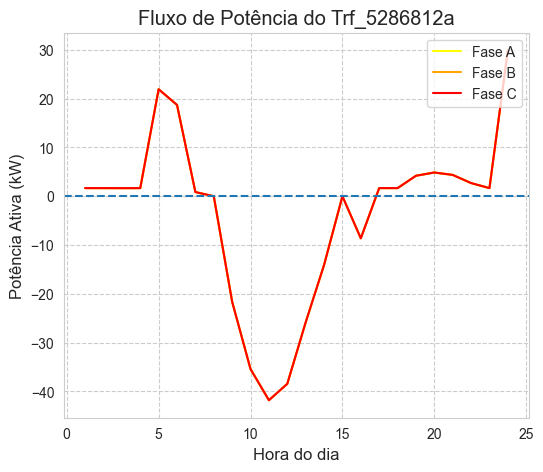

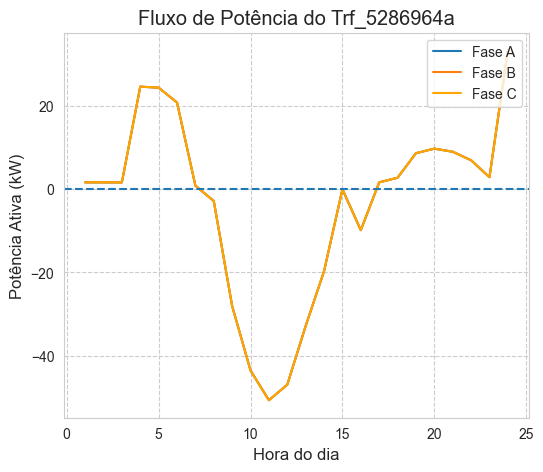

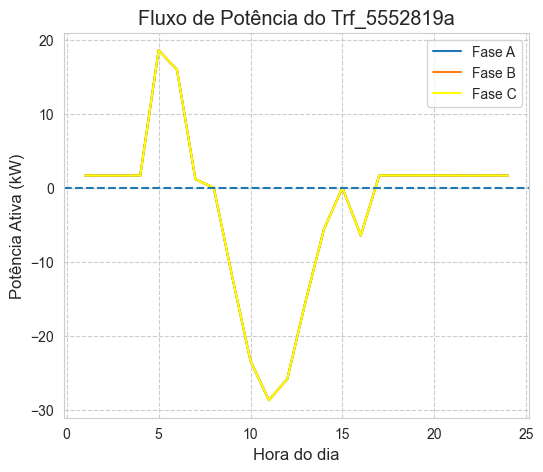

In [29]:
import matplotlib.pyplot as plt

df_trafo_1 = dss_tools.results.monitor("trf_5286812a")

df_trafo_2 = dss_tools.results.monitor("trf_5286964a")

df_trafo_3 = dss_tools.results.monitor("trf_5552819a")

#Trafo 1 = trf_5286812a
plt.plot(df_trafo_1["Hour"], df_trafo_1[" P1 (kW)"], label="Fase A", color="yellow")
plt.plot(df_trafo_1["Hour"], df_trafo_1[" P2 (kW)"], label="Fase B", color="orange")
plt.plot(df_trafo_1["Hour"], df_trafo_1[" P3 (kW)"], label="Fase C", color="red")
plt.xlabel("Hora do dia")
plt.ylabel("Potência Ativa (kW)")
plt.axhline(y=0, linestyle="--")
plt.legend()
plt.title("Fluxo de Potência do Trf_5286812a")
plt.show()

#Trafo 2 = trf_5286964a
plt.plot(df_trafo_2["Hour"], df_trafo_2[" P1 (kW)"], label="Fase A")
plt.plot(df_trafo_2["Hour"], df_trafo_2[" P2 (kW)"], label="Fase B")
plt.plot(df_trafo_2["Hour"], df_trafo_2[" P3 (kW)"], label="Fase C", color="orange")
plt.xlabel("Hora do dia")
plt.ylabel("Potência Ativa (kW)")
plt.axhline(y=0, linestyle="--")
plt.legend()
plt.title("Fluxo de Potência do Trf_5286964a")
plt.show()

#Trafo 2 = trf_5286964a
plt.plot(df_trafo_3["Hour"], df_trafo_3[" P1 (kW)"], label="Fase A")
plt.plot(df_trafo_3["Hour"], df_trafo_3[" P2 (kW)"], label="Fase B")
plt.plot(df_trafo_3["Hour"], df_trafo_3[" P3 (kW)"], label="Fase C", color="yellow")
plt.axhline(y=0, linestyle="--")
plt.xlabel("Hora do dia")
plt.ylabel("Potência Ativa (kW)")
plt.legend()
plt.title("Fluxo de Potência do Trf_5552819a")
plt.show()